![Alt text](ccats_logo.png)
# Tamm-Dancoff approximation for $n$ excited state with Jaynes-Cummings ($\text{TDA}_n-\text{JC}$)

#### **Reference:** https://doi.org/10.1063/5.0057542
---
## Overview
This tutorial serves as a continuation of the previous one (Lesson1_TDAJC) with multiple excited states models. 

By the end of this tutorial, you will be able to: 

1. **Part 1-** Understand the derivation of n-state JC models 
2. **Part 2-** Know how to compare the difference between $\text{TDA}_n-\text{JC}$ calculations
3. **Part 3-** Compare $\text{TDA}_n-\text{JC}$ and TDA-PF
4. **Part 4-** Capstone Exercise
---
## Environment Setup
### Option A: Running in Google Colab
If you opened this notebook in Google Colab, the environment configuration is handled automatically. 
1. Run the **Setup Cell** below. It will clone the repository, setup the directory structure, and install all dependencies.
2. Proceed to the **Verify Installation** section.

In [41]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Setting up Colab environment...")
    
    # Clone the repository to access local modules and data files
    !git clone https://github.com/cc-ats/molecular-polariton-modeling.git
    
    # Move into the repository directory
    %cd molecular-polariton-modeling
    
    # Install required packages
    !pip install -r requirements.txt
    
    print("Colab environment set up successfully!")
else:
    print("Running locally. No setup needed.")

Running locally. No setup needed.


### Option B: Running on Local Machine
If you are running it on your local computer, please refer to Lesson 1 for specific instruction on how to configure the environment. After that, execute the cell below.

### 📦 Imports & Configuration

In [42]:
import numpy as np
from pyscf import gto, scf, tdscf
import scipy
import qed
from qed.tdscf.ghf import FewLevel # Importing the FewLevel class from the qed package
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Color for printing
RED    = "\033[91m"
GREEN  = "\033[92m"
YELLOW = "\033[93m"
BLUE   = "\033[94m"
RESET  = "\033[0m"

#Unit Conversion:
HF_TO_EV = 27.2114
EV_TO_HF = 1 / HF_TO_EV

print("✅ All the imports are successful!")

✅ All the imports are successful!


---
# 🗂️ Part 1: Theoretical Framework
## 1.1 Ground State calculation
You can specify the structure and basis of the molecule directly in the following code block or any structual file. Then, run the ground state SCF calculation:

In [43]:
mol_file = 'ethene.xyz'  # Replace with your molecule file path
mol = gto.M(atom=mol_file, basis='6-311++G')
mf = scf.RKS(mol)
mf.xc = 'pbe0'
mf.kernel();

converged SCF energy = -76.6624395042442


## 1.2 n-state Jaynes-Cummings (JC) models

For a two-level system made of one electronic excited state $|e_1\rangle|0_\alpha\rangle$ and the cavity mode with one photon $|g\rangle|1_\alpha\rangle$ at resonance energy $\hbar\omega$, the two-state JC equation is:

$$
\begin{bmatrix}
\hbar\omega & s\hbar g_1\\
s\hbar g_1 & \hbar\omega
\end{bmatrix}
\begin{bmatrix}
X_1 \\ M
\end{bmatrix}
=
\hbar\Omega
\begin{bmatrix}
X_1 \\ M
\end{bmatrix},
\tag{1}
$$
where $s$ is a perturbation scaling factor (typically set to $1.0$ for standard calculations) and $g_1$ is the coupling coefficient:
$$g_k = \sqrt{\frac{\omega_c}{2}}(\boldsymbol{\lambda}\cdot\boldsymbol{\mu}_{0,k})$$
with $\omega_c$ being the cavity frequency, $\boldsymbol{\lambda}$ the coupling vector, and $\boldsymbol{\mu}_{0,k}$ the transition dipole moment between the ground state $|g\rangle$ and the $k$-th electronic excited state.

The solutions are the classic Lower and Upper Polariton states:

$$
|1_-\rangle = \frac{1}{\sqrt{2}}|e_1\rangle|0_\alpha\rangle-\frac{1}{\sqrt{2}}|g\rangle|1_\alpha\rangle, \\  
|1_+\rangle = \frac{1}{\sqrt{2}}|e_1\rangle|0_\alpha\rangle+\frac{1}{\sqrt{2}}|g\rangle|1_\alpha\rangle,
\tag{2}
$$
with energies:
$$
\hbar\Omega_{1_-}=\hbar\omega-s\hbar g_1,\\
\hbar\Omega_{1_+}=\hbar\omega+s\hbar g_1
\tag{3}
$$

When we introduce a second electronic excited state $|e_2\rangle|0_\alpha\rangle$ with excitation energy $\hbar\omega_2$, the basis expands to three states ($|e_2\rangle|0_\alpha\rangle$, $|e_1\rangle|0_\alpha\rangle$, $|g\rangle|1_\alpha\rangle$), and the JC equation becomes:

$$
\begin{bmatrix}
\hbar\omega_2 & 0 & s\hbar g_2 \\ 
0 & \hbar\omega & s\hbar g_1 \\ 
s\hbar g_2 & s\hbar g_1 & \hbar\omega
\end{bmatrix}
\begin{bmatrix}
X_2 \\ X_1 \\ M
\end{bmatrix}
=
\hbar\Omega'
\begin{bmatrix}
X_2 \\ X_1 \\ M
\end{bmatrix}
\tag{4}
$$

The off-diagonal couplings $s\hbar g_k$ represent the interaction between the photon mode and each respective electronic excited state, while direct electronic coupling between $|e_2\rangle|0_\alpha\rangle$ and $|e_1\rangle|0_\alpha\rangle$ is zero in this representation.

From here, we recommend you review the literature under APPENDIX C: TWO-STATE AND THREE-STATE JC MODELS for the full calculation.

## 1.3 Implementation
### 1.3.1 Transition Dipole
The transition dipole moments can be obtained directly from PySCF. One can also adjust `.nroots` attribute to include more electronic state calculations.

**Note on Oscillator Strength:** The `oscillator_strength()` represents the dimensionless probability of a molecule interacting with electromagnetic radiation to undergo a specific electronic transition. A higher value indicates a brighter state. In cavity QED simulations, we typically align the cavity field polarization ($\vec{\epsilon}$) with the transition dipole moment ($\vec{d}_{ig}$) of the brightest state to achieve the maximum possible light-matter coupling strength.

Excecute the cell below to obtain the brightest excitation energy and transition dipole moments (refer to previous tutorial for more detail.

In [44]:
td = tdscf.TDA(mf)
td.nroots = 20 # Solve for more electronic states 
td.kernel()

osc = td.oscillator_strength()
bright_idx = np.argmax(osc[:5])  # Find the index of the brightest excitation among the first 5 states
target_energy = td.e[bright_idx]
trans_dip = td.transition_dipole()[bright_idx]
print(f"Brightest excitation energy: {target_energy:.4f} a.u. ({target_energy * HF_TO_EV:.4f} eV)")
print(f"Transition dipole moment: {trans_dip} a.u.")

Excitation energies (eV)
[ 9.103047  9.81183   9.889254 10.281365 10.785216 10.91316  10.946406
 11.068171 11.115581 11.161903 11.652168 11.756753 12.107722 12.256296
 12.702297 12.801767 12.921076 13.063502 13.406841 13.406849]
Brightest excitation energy: 0.3345 a.u. (9.1031 eV)
Transition dipole moment: [-3.728731e-15 -5.844364e-15 -5.813733e-01] a.u.


### 1.3.2 Setup $\text{TDA}_n-\text{JC}$
The `FewLevel` model is a **reduced-basis approximation** that simplifies the complex light-matter interaction by focusing only on a handful of key electronic excitations. 

To run it, we specify the cavity parameters, and configure the solver settings:

> ❗
> **Note on `nstates` Parameters:**
> In `FewLevel` modeling, the term `nstates` is used in two different contexts:
> 1. **`qed_obj.nstates` (object attribute):** Specifies the number of **polaritonic** states (roots) to solve for and retrieve. For example, if we include $N$ electronic states and $1$ photon mode, the total basis size is $N+1$, so we set `qed_obj.nstates = n_electronic_states + 1`.
> 2. **`qed_obj.kernel(nstates=...)` (argument):** Specifies the number of **electronic** states (excitations) from the uncoupled TDA calculation to include in constructing the low-dimensional Hamiltonian matrix.

Execute the cell below to configure and run the model.

In [45]:
unit_dip = trans_dip / np.linalg.norm(trans_dip)

lambda_coupling = 0.05  # Coupling strength in a.u.
cavity_mode = (unit_dip * lambda_coupling).reshape(3, 1)  # Reshape to a column vector
n_electronic_states = 5

key = {
    'cavity_freq': target_energy,  # Resonant with the brightest excitation
    'cavity_mode': cavity_mode
}

# Create the TDA_JC object
cav_obj = qed.JC(mf, key)

# Initialize the FewerLevel model
qed_obj = FewLevel(td, cav_obj, key)
qed_obj.cavity_model = 'JC'
qed_obj.nstates = n_electronic_states+1
qed_obj.target_states = 'polariton'
qed_obj.solver_algorithm = 'direct'
qed_obj.solver_conv_prop = 'norm'
qed_obj.level_shift = 0.0
qed_obj.tolerance = 1e-8
qed_obj.max_cycle = 100

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1


### 1.3.3 Run The kernel
```nstates``` in the kernel defines how many electronic excitations to include in the Hamiltonian construction.

In [46]:
energies, vectors, trans_dips, mag_dip = qed_obj.kernel(nstates=n_electronic_states)

print(f"Number of states found: {len(energies)}")
print(f"Polaritonic energies (in eV): {energies * HF_TO_EV}")

has_offdiag inter-fragment coupling? False
Number of states found: 6
Polaritonic energies (in eV): [ 8.779548  9.426555  9.811835  9.88926  10.281371 10.785221]


### 1.3.4 🏋️ **Exercise : Convergence with Number of States**
The `FewLevel` approximation relies on including enough electronic states to accurately capture the polariton spectrum.
*   **Task:** For a fixed coupling strength (e.g., $\lambda = 0.1$ a.u.), systematically increase the number of electronic states (`n_electronic_states`) from 1 to 10 in your `FewLevel` model.
*   **Question:** How many states does it take for the lower and upper polariton energies to converge? Does the required number of states depend on the coupling strength?

In [47]:
# TODO: Pick a coupling strength and increase the number of electronic states
lambda_coupling = 0.1
unit_dip = trans_dip / np.linalg.norm(trans_dip)
cavity_mode = (unit_dip * lambda_coupling).reshape(3, 1)
key_ex1 = {'cavity_freq': target_energy, 'cavity_mode': cavity_mode}

print("Converging FewLevel model states at lambda = 0.1 a.u. ...")
for n_estates in range(1, 21):
    cav_obj_ex1 = qed.JC(mf, key_ex1)
    qed_obj_ex1 = FewLevel(td, cav_obj_ex1, key_ex1)
    qed_obj_ex1.cavity_model = 'JC'
    qed_obj_ex1.nstates = n_estates + 1
    qed_obj_ex1.target_states = 'polariton'
    qed_obj_ex1.solver_algorithm = 'direct'
    qed_obj_ex1.solver_conv_prop = 'norm'
    qed_obj_ex1.level_shift = 0.0
    qed_obj_ex1.max_cycle = 100
    qed_obj_ex1.tolerance = 1e-8
    
    e, v, _, _ = qed_obj_ex1.kernel(nstates=n_estates)
    print(f"n_electronic_states = {n_estates:2d} -> Polariton energies (eV): {e * HF_TO_EV}")

Converging FewLevel model states at lambda = 0.1 a.u. ...
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
n_electronic_states =  1 -> Polariton energies (eV): [8.456044 9.750058]
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
n_electronic_states =  2 -> Polariton energies (eV): [8.456044 9.750058 9.811835]
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
n_electronic_states =  3 -> Polariton energies (eV): [8.456044 9.750058 9.811835 9.88926 ]
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
n_electronic_states =  4 -> Polariton energies (eV): [ 8.456044  9.750058  9.811835  9.88926  10.281371]
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coup

### 1.3.5 🏋️ **Exercise : FewLevel vs. Full Ab Initio**
The `FewLevel` model (`solver_algorithm = 'direct'`) is an approximation of the full QED-TDA equations.
*   **Task:** Change the `solver_algorithm` from `'direct'` to `'davidson_qr'` to run the full ab initio TDA-JC calculation for $\lambda = 0.1$ a.u.
*   **Question:** How much do the polariton energies differ between the `FewLevel` approximation and the full ab initio calculation? 

In [48]:
# TODO: Implement Full Ab Initio
lambda_coupling = 0.1
unit_dip = trans_dip / np.linalg.norm(trans_dip)
cavity_mode = (unit_dip * lambda_coupling).reshape(3, 1)
key_ex2 = {'cavity_mode': cavity_mode, 'cavity_freq': np.array([target_energy])}

# 1. Run Full Ab Initio QED-TDA JC model (set nroots=5 for stable convergence)
print("Running Full Ab Initio TDA-JC...")
cav_jc_abi = qed.JC(mf, key_ex2)
qed_td_jc = qed.TDA(mf, td, cav_jc_abi, key_ex2)
qed_td_jc.nroots = 5
qed_td_jc.kernel()
print(f"Ab Initio energies (eV): {qed_td_jc.e * HF_TO_EV}")

# 2. Run FewLevel JC model (n_electronic_states = 5)
print("\nRunning FewLevel JC (n_electronic_states = 5)...")
cav_fl_ex2 = qed.JC(mf, key_ex2)
qed_fl_ex2 = FewLevel(td, cav_fl_ex2, key_ex2)
qed_fl_ex2.cavity_model = 'JC'
qed_fl_ex2.nstates = 6
qed_fl_ex2.target_states = 'polariton'
qed_fl_ex2.solver_algorithm = 'direct'
qed_fl_ex2.solver_conv_prop = 'norm'
qed_fl_ex2.level_shift = 0.0
qed_fl_ex2.max_cycle = 100
qed_fl_ex2.tolerance = 1e-8
e_fl, _, _, _ = qed_fl_ex2.kernel(nstates=5)
print(f"FewLevel energies (eV): {e_fl * HF_TO_EV}")

Running Full Ab Initio TDA-JC...
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.3014   0.349993 0.360578 0.363423 0.377833]
Ab Initio energies (eV): [ 8.201524  9.523807  9.811835  9.88926  10.281371]

Running FewLevel JC (n_electronic_states = 5)...
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
FewLevel energies (eV): [ 8.456044  9.750058  9.811835  9.88926  10.281371 10.785221]


### 1.3.6 Scanning Coupling Strength

Here we apply the same algorithm as above for many coupling strengths

In [49]:
lambdas = np.linspace(0, 0.10, 20)

results_energies = []
photon_contribution = []

for lam in lambdas:
    print(f"{GREEN}Coupling lam = {lam:.3f} au...{RESET}", end="\r")

    # Update the cavity coupling strength
    key['cavity_mode'] = (unit_dip * lam).reshape(3, 1)
    
    # Re-initialize cavity and model
    cav_obj = qed.JC(mf, key)
    qed_obj = FewLevel(td, cav_obj, key)
    qed_obj.cavity_model = 'JC'
    qed_obj.nstates = n_electronic_states+1
    qed_obj.target_states = 'polariton'
    qed_obj.solver_algorithm = 'direct'
    qed_obj.solver_conv_prop = 'norm'
    qed_obj.level_shift = 0.0
    qed_obj.tolerance = 1e-8
    qed_obj.max_cycle = 100

    # Solve for polaritons 
    e, v, _, _ = qed_obj.kernel(nstates=n_electronic_states)

    # Extract photon weights
    wp, we = qed_obj.get_weights(v)

    results_energies.append(e)
    photon_contribution.append(wp)

    print(f"Coupling: {lam:.3f} a.u., Polariton Energies: {e}")
    print(f"{YELLOW}----------------------------------------------------------------{RESET}")

results_energies = np.array(results_energies) * HF_TO_EV  # Convert to eV
print(f"Shape of results: {results_energies.shape}") # Keep as probabilities (0 to 1)

scf_type: RKS lam = 0.000 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
Coupling: 0.000 a.u., Polariton Energies: [0.334531 0.334531 0.360578 0.363423 0.377833 0.396349]
----------------------------------------------------------------
scf_type: RKS lam = 0.005 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
Coupling: 0.005 a.u., Polariton Energies: [0.333279 0.335782 0.360578 0.363423 0.377833 0.396349]
----------------------------------------------------------------
scf_type: RKS lam = 0.011 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
Coupling: 0.011 a.u., Polariton Energies: [0.332028 0.337034 0.360578 0.363423 0.377833 0.396349]
----------------------------------------------------------------
scf_type: RKS lam = 0.016 au...
occupation: 2
has_offdiag 

---
# 📊 Part 2: Generate Plot for Polariton States within FewLevel Model

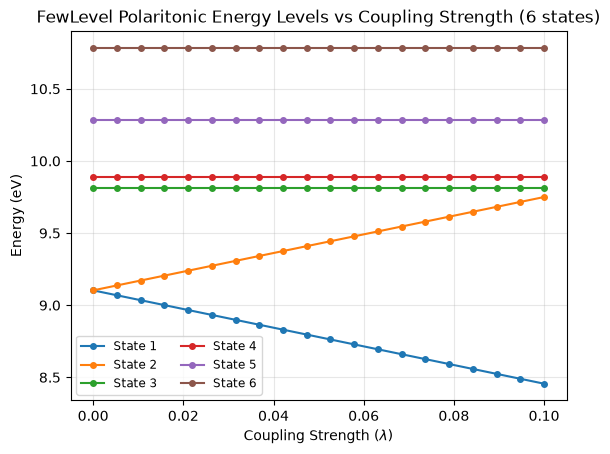

In [50]:
import matplotlib.cm as cm

# Generate colors based on actual number of states
n_states = results_energies.shape[1]
colors = cm.tab10(np.linspace(0, 1, max(n_states, 10)))

for i in range(n_states):
    plt.plot(lambdas, results_energies[:, i], label=f'State {i+1}', color=colors[i], marker='o', markersize=4)

plt.xlabel('Coupling Strength ($\\lambda$)')
plt.ylabel('Energy (eV)')
plt.title(f'FewLevel Polaritonic Energy Levels vs Coupling Strength ({n_states} states)')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)

plt.show()

---
# 📋 Part 3: Tamm-Dancoff approximation Pauli-Fierz (TDA-PF) model
The key equation we are trying to solve in this model is 

$$
\begin{bmatrix}
\mathbf{A} + \Delta & \hbar \mathbf{g}^{\dagger} & \hbar \tilde{\mathbf{g}}^{\dagger} \\
\hbar \mathbf{g} & \hbar \mathbf{\omega} & 0 \\
\hbar \tilde{\mathbf{g}} & 0 & \hbar \mathbf{\omega}
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M} \\ \mathbf{N}
\end{bmatrix}
=
\hbar\Omega^{\text{TDA-PF}}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & -1 
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M} \\ \mathbf{N}
\end{bmatrix}
$$

To implement this using the ```qed``` package, we follow the same procedure as TDA-JC, but instead using the ```.PF``` attribute

## 3.1 Run TDA-PF

In [51]:
unit_dip = trans_dip / np.linalg.norm(trans_dip)

lambda_coupling = 0.1
cavity_mode = (unit_dip * lambda_coupling).reshape(3, 1)

key = {
    'cavity_mode': cavity_mode,
    'cavity_freq': np.array([target_energy])
}

cav_model = qed.PF(mf, key)
qed_td = qed.TDA(mf, td, cav_model, key)

qed_td.nroots = 5 
qed_td.kernel()
print("Polartion Energies using TDA-PF (in a.u.):", qed_td.e)

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedPauliFierz Polariton State energies (au)
[0.303651 0.349686 0.360578 0.362552 0.40849 ]
Polartion Energies using TDA-PF (in a.u.): [0.303651 0.349686 0.360578 0.362552 0.40849 ]


## 3.2 Compare TDA-JC and TDA-PF
Here, we compare the two model over a range of coupling strengths to observe the difference between them. Since PF model includes the Dipole Self-Energy (DSE) term $\frac{1}{2}(d \cdot \epsilon)^2$, it prevents the groud state energy from artificially collapsing at high coupling strength, which is a known failure in the JC model. 

scf_type: RKS lam = 0.000 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.334531 0.334531 0.360578 0.363423 0.377833]
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedPauliFierz Polariton State energies (au)
[0.334531 0.334531 0.360578 0.363423 0.40849 ]
scf_type: RKS lam = 0.005 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.333253 0.335756 0.360578 0.363423 0.377833]
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedPauliFierz Polariton State energies (au)
[0.333256 0.335759 0.360578 0.363423 0.40849 ]
scf_type: RKS lam = 0.011 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.331922 0.336929 0.360578 0.363423 0.37

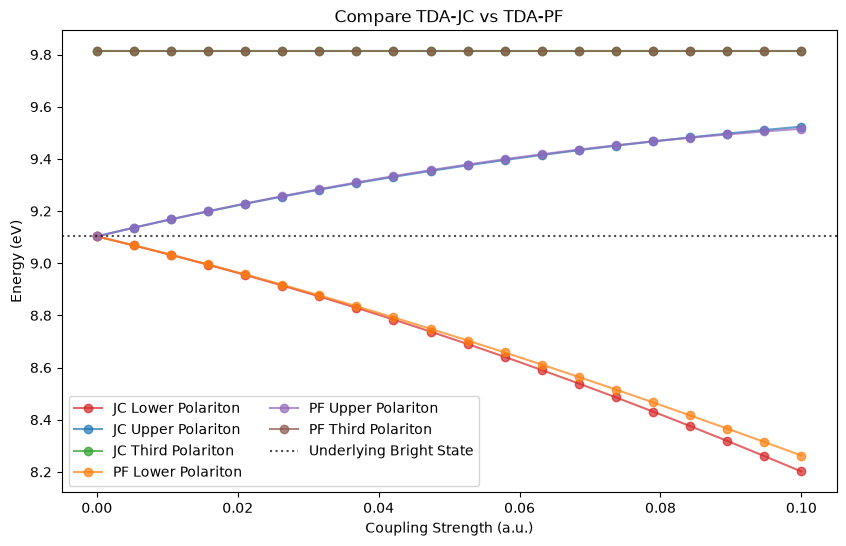

In [52]:
JC_energies = []
PF_energies = []

cavity_freqs = np.array([target_energy])

for lam in lambdas:
    print(f"{RED}Coupling lam = {lam:.3f} au...{RESET}", end="\r")
    unit_dip = trans_dip / np.linalg.norm(trans_dip)
    cavity_mode = (unit_dip * lam).reshape(3, 1)
    key = {
        'cavity_mode': cavity_mode,
        'cavity_freq': cavity_freqs
    }
    # JC model
    cav_jc = qed.JC(mf, key)
    td_jc = qed.TDA(mf, td, cav_jc, key)
    td_jc.nroots = 5
    td_jc.kernel()
    JC_energies.append(td_jc.e)

    # PF model
    cav_pf = qed.PF(mf, key)
    td_pf = qed.TDA(mf, td, cav_pf, key)
    td_pf.nroots = 5
    td_pf.kernel()
    PF_energies.append(td_pf.e)

JC_energies = np.array(JC_energies)
PF_energies = np.array(PF_energies)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, JC_energies[:, 0] * HF_TO_EV, color='tab:red', marker='o', markersize=6, alpha=0.7, label='JC Lower Polariton')
plt.plot(lambdas, JC_energies[:, 1] * HF_TO_EV, color='tab:blue',marker='o', markersize=6, alpha=0.7, label='JC Upper Polariton')
plt.plot(lambdas, JC_energies[:, 2] * HF_TO_EV, color='tab:green', marker='o', markersize=6, alpha=0.7, label='JC Third Polariton')

plt.plot(lambdas, PF_energies[:, 0] * HF_TO_EV, color='tab:orange', marker='o', markersize=6, alpha=0.7, label='PF Lower Polariton')
plt.plot(lambdas, PF_energies[:, 1] * HF_TO_EV, color='tab:purple',marker='o', markersize=6, alpha=0.7, label='PF Upper Polariton')
plt.plot(lambdas, PF_energies[:, 2] * HF_TO_EV, color='tab:brown', marker='o', markersize=6, alpha=0.7, label='PF Third Polariton')

plt.axhline(y=target_energy * HF_TO_EV, color='black', linestyle=':', alpha=0.7, label='Underlying Bright State')

plt.xlabel('Coupling Strength (a.u.)')
plt.ylabel('Energy (eV)')
plt.title('Compare TDA-JC vs TDA-PF')
plt.legend(ncol=2)
plt.show()


## 3.3 🏋️ Exercise 3: The Rotating Wave Approximation (RWA)
The JC model neglects both dipole self-energy and counter-rotating terms (CRTs). The RWA model includes DSE but neglects CRTs.
*   **Task:** Change the `cavity_model` parameter from `'JC'` to `'RWA'` in your `FewLevel` scan, or run the ab initio comparison by instantiating `cav_rwa = qed.RWA(mf, key)` and `qed_td_rwa = qed.TDA(mf, td, cav_rwa, key)`.
*   **Question:** How does the inclusion of the Dipole Self-Energy in the RWA model affect the polariton energies compared to the pure JC model, especially at high coupling strengths?

---
# 🏆 Part 4: Capstone Challenge - Navigating the QED-TDDFT Prism
Now that you have explored the individual approximations (`FewLevel` convergence, full ab initio solvers, and the JC vs. PF models), it is time to put it all together.

Imagine you are investigating a new, highly polar molecule—Hydrogen Fluoride (HF)—placed inside a highly confined optical cavity where the coupling strength reaches the ultra-strong regime ($\lambda = 0.15$ a.u.).

Your task is to determine the most computationally efficient way to calculate the true polaritonic energies without sacrificing physical accuracy.

**The Setup**  

First, initialize your molecule and target the brightest excitation:

In [53]:
# Molecule geometry (feel freee to change to a different system)
geom_HF = 'H 0.0 0.0 0.0; F 0.0 0.0 0.917'
mol_HF = gto.M(atom=geom_HF, basis='6-311++G**')

# TODO: You will need to run the ground state SCF and standard TDDFT here

### **Your Tasks & Reference Answers:**

**1. The Ground Truth (Full Ab Initio)**

Set up a TDA-PF cavity model for HF at $\lambda = 0.15$ a.u. Use the full `davidson_qr` solver (by instantiating `qed.PF` and running `qed.TDA` with `nroots=5` for stable convergence under degeneracy) to calculate the exact, un-truncated polariton energies. Record the energy of the Lower Polariton.
*   *Reference Answer:* The Ground Truth Lower Polariton energy is **$\approx 9.9702$ eV**.

**2. The Model Breakdown**

Using the `FewLevel` solver with `nstates = 5`, calculate the Lower Polariton energy using all three cavity models: `'JC'`, `'RWA'`, and `'PF'`.

*   *Reference Answer:* 
    *   JC LP Energy: **$\approx 9.7916$ eV** (shows a large, unphysical shift due to missing DSE).
    *   RWA LP Energy: **$\approx 9.9733$ eV** (including DSE restores stability).
    *   PF LP Energy: **$\approx 9.9733$ eV**.

**3. The Convergence Hunt**

Your `FewLevel` PF model from Task 2 was likely still quite far from the Ground Truth because `nstates = 5` is insufficient for ultra-strong coupling.

*   **Task:** Write a loop that systematically increases `nstates` in your `FewLevel` PF model from 5 up to 30.
*   **Reference Answer:** The `FewLevel` PF model LP energy converges to within $0.001$ eV (1 meV) of the full ab initio Ground Truth at exactly **$n_{\text{electronic\_states}} = 9$** (where LP energy is $9.9706$ eV, diff = $0.43$ meV).
*   **Symmetry & Physics Insight:** Hydrogen Fluoride (HF) is aligned along the Z axis, and the cavity mode is also polarized along Z. In this configuration, only electronic states with $\Sigma^+$ symmetry (which have transition dipoles along Z) couple to the cavity and the Dipole Self-Energy (DSE). The first $\Sigma^+$ state is at index 4 (included in $n=5$). The second $\Sigma^+$ state is at index 8 (included when $n \ge 9$). Including the 9th state adds the necessary DSE contribution of the second $\Sigma^+$ state, completing the physics needed to converge the Lowest Polariton energy.

**Why this matters:**

By completing this challenge, you have just executed a standard computational physics workflow: you established a rigorous (but expensive) benchmark, analyzed the physical validity of simpler Hamiltonians, and systematically converged a fast approximation until it matched the exact physics. You are now ready to apply these models to complex, multi-molecular systems!

In [54]:
# 🏆 Task 1: The Ground Truth (Full Ab Initio TDA-PF)
print("Running ground state SCF and standard TDDFT for HF...")
mf_HF = scf.RKS(mol_HF)
mf_HF.xc = 'pbe0'
mf_HF.kernel()

td_HF = tdscf.TDA(mf_HF)
td_HF.nroots = 30
td_HF.kernel()

# Identify targeted bright state:
osc = td_HF.oscillator_strength()
bright_idx = np.argmax(osc)
target_energy = td_HF.e[bright_idx]
trans_dip = td_HF.transition_dipole()[bright_idx]
print(f"Target bright state: {bright_idx}, at {target_energy*HF_TO_EV:.4f} eV")

# Setup cavity at lambda = 0.15 a.u.
unit_dip = trans_dip / np.linalg.norm(trans_dip)
lambda_coupling = 0.15
cavity_mode = (unit_dip * lambda_coupling).reshape(3, 1)

key_cap = {
    'cavity_mode': cavity_mode,
    'cavity_freq': np.array([target_energy]),
}

# Initialize and solve the full ab initio TDA-PF model
# (We set nroots=5 to handle degenerate target state stably)
cav_pf = qed.PF(mf_HF, key_cap)
qed_td_pf = qed.TDA(mf_HF, td_HF, cav_pf, key_cap)
qed_td_pf.nroots = 5
qed_td_pf.kernel()

ground_truth_lp = qed_td_pf.e[0] * HF_TO_EV
print(f"\nGround Truth LP Energy: {ground_truth_lp:.6f} eV")

Running ground state SCF and standard TDDFT for HF...
converged SCF energy = -100.383021155718
Excitation energies (eV)
[ 9.791555  9.791555 13.373713 13.373713 13.853706 15.420877 15.428866
 15.428867 15.906433 15.906433 16.674081 18.479955 18.479955 18.969899
 19.251363 19.251363 20.451695 22.281483 22.699906 22.699906 28.443277
 32.190562 35.667018 37.637126 37.637126 37.984879 40.477001 42.022868
 42.088683 42.088683]
Target bright state: 20, at 28.4433 eV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
RestrictedPauliFierz Polariton State energies (au)
[0.366398 0.366398 0.495896 0.495896 0.504981]

Ground Truth LP Energy: 9.970192 eV


In [55]:
# 🏆 Task 2: The Model Breakdown (FewLevel at n_electronic_states = 5)
models = ['JC', 'RWA', 'PF']

for model in models:
    # Initialize cavity model
    if model == 'JC':
        cav_fl = qed.JC(mf_HF, key_cap)
    elif model == 'RWA':
        cav_fl = qed.RWA(mf_HF, key_cap)
    else:
        cav_fl = qed.PF(mf_HF, key_cap)
        
    # Set up FewLevel solver
    qed_obj = FewLevel(td_HF, cav_fl, key_cap)
    qed_obj.cavity_model = model
    qed_obj.nstates = 6 # 5 electronic + 1 photon mode = 6 polariton roots
    qed_obj.target_states = 'polariton'
    qed_obj.solver_algorithm = 'direct'
    qed_obj.solver_conv_prop = 'norm'
    qed_obj.level_shift = 0.0
    qed_obj.max_cycle = 100
    qed_obj.tolerance = 1e-8
    
    # Run kernel with 5 electronic states
    e, v, _, _ = qed_obj.kernel(nstates=5)
    print(f"FewLevel {model} LP Energy: {e[0] * HF_TO_EV:.6f} eV")

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
FewLevel JC LP Energy: 9.791560 eV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
FewLevel RWA LP Energy: 9.973252 eV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
FewLevel PF LP Energy: 9.973252+0.000000j eV


In [56]:
# 🏆 Task 3: The Convergence Hunt
# Loop to systematically increase n_electronic_states from 5 to 30
for n_estates in range(5, 31):
    cav_fl = qed.PF(mf_HF, key_cap)
    qed_obj = FewLevel(td_HF, cav_fl, key_cap)
    qed_obj.cavity_model = 'PF'
    qed_obj.nstates = n_estates + 1
    qed_obj.target_states = 'polariton'
    qed_obj.solver_algorithm = 'direct'
    qed_obj.solver_conv_prop = 'norm'
    qed_obj.level_shift = 0.0
    qed_obj.max_cycle = 100
    qed_obj.tolerance = 1e-8
    
    e, v, _, _ = qed_obj.kernel(nstates=n_estates)
    lp_ev = e[0] * HF_TO_EV
    diff = abs(lp_ev - ground_truth_lp)
    
    print(f"n_electronic_states = {n_estates}: LP = {lp_ev:.6f} eV, diff = {diff*1000:.3f} meV")
    if diff < 0.001:
        print(f"--> Converged to within 1 meV at n_electronic_states = {n_estates}!")
        break

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
n_electronic_states = 5: LP = 9.973252+0.000000j eV, diff = 3.060 meV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
n_electronic_states = 6: LP = 9.973252+0.000000j eV, diff = 3.060 meV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
n_electronic_states = 7: LP = 9.973252+0.000000j eV, diff = 3.060 meV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
n_electronic_states = 8: LP = 9.973252+0.000000j eV, diff = 3.060 meV
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 21
has_offdiag inter-fragment coupling? False
n_electronic_states = 9: LP = 9.970622+0.000000j e